In [1]:
%matplotlib inline

In [2]:
"""
Heatmap_Chile_Combinado.ipynb
Figura combinada: mapa Chile por región + zoom Región Metropolitana por comuna
Ventas brutas SII 2024 — % respecto al total nacional
Diego Carmine Ortiz — Memoria de Título UdeC Ingeniería Industrial
"""

import warnings, os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib import rcParams
from shapely.geometry import box
from IPython.display import display
warnings.filterwarnings("ignore")

rcParams["font.family"] = "serif"
rcParams["font.serif"]  = ["DejaVu Serif", "Georgia", "Times New Roman"]
rcParams["figure.dpi"]  = 150

In [3]:

# ══════════════════════════════════════════════════════════════════════════════
# PARÁMETROS (extraídos del notebook de referencia Heatmap_Chile_STG.ipynb)
# ══════════════════════════════════════════════════════════════════════════════

SII_PATH      = "/Users/diego/Desktop/MT/Datos/PUB_TRAM_COMU (1).xlsb"
SHP_PATH      = "/Users/diego/Desktop/MT/Datos/shapefiles/Comunas"
ANIO_CL       = 2024
BBOX_CHILE    = (-76.0, -56.0, -65.5, -17.0)
# Bounding box ampliado: este extendido a -70.10 para incluir Las Condes completa
BBOX_STGO     = (-71.10, -33.75, -70.10, -33.20)
AREA_MIN_DEG2 = 0.05   # umbral islotes (~500 km²)

MARCAS_CLASE = {
    "Micro 1": 100,       "Micro 2": 400,       "Micro 3": 1_500,
    "Pequeña 1": 6_200,   "Pequeña 2": 17_500,  "Pequeña 3": 50_000,
    "Mediana 1": 137_500, "Mediana 2": 400_000,
    "Grande 1": 1_300_000, "Grande 2": 3_500_000,
    "Grande 3": 7_500_000, "Grande 4": 15_000_000,
}

COMUNAS_EXCLUIR = {
    "Sin Información", "Sin Ventas/Sin Información",
    "Tramo según ventas (13 tramos)", "Tramo según ventas (5 tramos)",
}

COMUNAS_STGO_CENTRO = {
    "Las Condes", "Vitacura", "Providencia", "Santiago", "Ñuñoa",
    "La Reina", "Macul", "San Miguel", "Estación Central", "Quinta Normal",
    "Recoleta", "Independencia", "Conchalí", "Renca", "Cerro Navia",
    "Lo Prado", "Peñalolén", "Pedro Aguirre Cerda", "Cerrillos",
    "Lo Espejo", "La Cisterna", "La Granja", "San Joaquín", "La Florida",
    "Maipú", "San Ramón", "El Bosque", "La Pintana", "Pudahuel",
    "San Bernardo", "Puente Alto", "Huechuraba", "Quilicura",
}

CMAP = LinearSegmentedColormap.from_list("academic_seq", [
    "#fffbf0", "#fee8a0", "#fecc5c", "#fd8d3c",
    "#f03b20", "#bd0026", "#67000d",
], N=256)

ETIQUETAS = {
    "Región Metropolitana de Santiago":               "R.M. Santiago",
    "Región de Valparaíso":                           "Valparaíso",
    "Región del Biobío":                              "Biobío",
    "Región del Bío-Bío":                             "Biobío",
    "Región de Antofagasta":                          "Antofagasta",
    "Región de La Araucanía":                         "La Araucanía",
    "Región de Los Lagos":                            "Los Lagos",
    "Región Aisén del Gral.Carlos Ibáñez del Campo":  "Aysén",
    "Región Aisén del Gral.Ibañez del Campo":         "Aysén",
    "Región de Magallanes y de la Antártica Chilena": "Magallanes",
    "Región de Magallanes y Antártica Chilena":       "Magallanes",
    "Región de Atacama":                              "Atacama",
    "Región de Coquimbo":                             "Coquimbo",
    "Región del Maule":                               "Maule",
    "Región del Libertador Gral. Bernardo O'Higgins": "O'Higgins",
    "Región del Libertador Bernardo O'Higgins":       "O'Higgins",
    "Región de Los Ríos":                             "Los Ríos",
    "Región de Arica y Parinacota":                   "Arica y\nParinacota",
    "Región de Tarapacá":                             "Tarapacá",
    "Región de Ñuble":                                "Ñuble",
}


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. CARGA Y LIMPIEZA DATOS SII
# ══════════════════════════════════════════════════════════════════════════════

print("Cargando SII...")
sii = pd.read_excel(SII_PATH, engine="pyxlsb", skiprows=3)
sii.columns = (
    ["anio", "tramo13", "tramo5", "comuna", "provincia", "region",
     "n_empresas", "ventas_uf"] + [f"_c{i}" for i in range(18)]
)
sii["anio"] = pd.to_numeric(sii["anio"], errors="coerce")

def impute_v(row):
    v = row["ventas_uf"]
    if v == "*":
        try:    return MARCAS_CLASE[row["tramo13"]] * float(row["n_empresas"])
        except: return 0.0
    try:    return float(v)
    except: return 0.0

sii["v"] = sii.apply(impute_v, axis=1)

sii_filt = sii[
    (sii["anio"] == ANIO_CL) &
    sii["tramo13"].isin(MARCAS_CLASE) &
    ~sii["comuna"].isin(COMUNAS_EXCLUIR)
].copy()

# Total nacional
total_nac = sii_filt["v"].sum()

# ── Datos por región ──────────────────────────────────────────────────────────
reg_data = (
    sii_filt.groupby("region")["v"]
    .sum().reset_index()
    .rename(columns={"v": "ventas_uf"})
)
reg_data["pct"] = reg_data["ventas_uf"] / total_nac * 100
reg_data["region"] = reg_data["region"].str.strip()
reg_data = reg_data[reg_data["region"] != "Sin Información"]
_region_norm = reg_data["region"].str.replace("\u2019", "'", regex=False)
reg_data["etiqueta"] = _region_norm.map(ETIQUETAS).fillna(reg_data["region"])

# ── Datos por comuna RM (TODAS las comunas de la RM) ─────────────────────────
rm_sii = sii_filt[
    sii_filt["region"].str.contains("Metropolitana", na=False)
].copy()
rm_data = (
    rm_sii.groupby("comuna")["v"]
    .sum().reset_index()
    .rename(columns={"v": "ventas_uf"})
)
total_rm           = rm_data["ventas_uf"].sum()
rm_data["pct_nac"] = rm_data["ventas_uf"] / total_nac * 100
rm_data["pct_rm"]  = rm_data["ventas_uf"] / total_rm  * 100
rm_data["comuna"]  = rm_data["comuna"].str.strip()
pct_rm_total       = rm_data["pct_nac"].sum()

print(f"  Total nacional: {total_nac/1e6:,.1f} MM UF")
print(f"  {len(reg_data)} regiones cargadas")
print(f"  RM: {len(rm_data)} comunas | {pct_rm_total:.1f}% ventas nac.")


Cargando SII...
  Total nacional: 45,925.1 MM UF
  16 regiones cargadas
  RM: 52 comunas | 66.5% ventas nac.


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. SHAPEFILE — limpieza de islotes
# ══════════════════════════════════════════════════════════════════════════════

print("Cargando shapefile...")
geo = gpd.read_file(SHP_PATH).to_crs("EPSG:4326")
geo["geometry"] = geo["geometry"].make_valid()

# ── Shapefile regional (Chile) ────────────────────────────────────────────────
reg_geo_raw = (
    geo.clip(box(*BBOX_CHILE))
    .dissolve(by="Region")
    .reset_index()[["Region", "geometry"]]
)
reg_geo_raw["geometry"] = reg_geo_raw["geometry"].make_valid()
reg_exp      = reg_geo_raw.explode(index_parts=False).reset_index(drop=True)
reg_exp["_area"] = reg_exp.geometry.area
reg_exp_clean = reg_exp[reg_exp["_area"] >= AREA_MIN_DEG2].drop(columns="_area")
reg_geo = (
    reg_exp_clean.dissolve(by="Region")
    .reset_index()[["Region", "geometry"]]
)
reg_geo["geometry"] = reg_geo["geometry"].make_valid()
print(f"  Polígonos Chile: {len(reg_exp):,} → {len(reg_exp_clean):,} (sin islotes)")

# ── Merge Chile ───────────────────────────────────────────────────────────────
reg_merged = reg_geo.merge(
    reg_data[["region", "pct", "etiqueta"]],
    left_on="Region", right_on="region",
    how="left",
)
reg_merged["pct"]      = reg_merged["pct"].fillna(0)
reg_merged["etiqueta"] = reg_merged["etiqueta"].fillna(
    reg_merged["Region"].map(ETIQUETAS).fillna(reg_merged["Region"])
)

# ── Shapefile comunas RM — REGIÓN COMPLETA sin recorte ───────────────────────
geo["Comuna"] = geo["Comuna"].str.strip()
geo["Region"] = geo["Region"].str.strip()
rm_geo = geo[
    geo["Region"].str.contains("Metropolitana", na=False)
].copy()
rm_geo["geometry"] = rm_geo["geometry"].make_valid()

rm_merged = rm_geo.merge(
    rm_data[["comuna", "pct_nac", "pct_rm"]],
    left_on="Comuna", right_on="comuna",
    how="left",
)
rm_merged["pct_nac"] = rm_merged["pct_nac"].fillna(0)
rm_merged["pct_rm"]  = rm_merged["pct_rm"].fillna(0)
rm_merged = rm_merged[rm_merged.geometry.notna()].reset_index(drop=True)
print(f"  Comunas RM: {len(rm_merged)}")


Cargando shapefile...
  Polígonos Chile: 9,793 → 51 (sin islotes)
  Comunas RM: 52


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. ESTADÍSTICAS
# ══════════════════════════════════════════════════════════════════════════════

# Gini Chile (entre regiones)
_v_cl = reg_data.sort_values("pct")["pct"].values / 100
gini_cl = round(1 - 2 * np.trapezoid(
    np.insert(np.cumsum(_v_cl), 0, 0),
    np.insert(np.arange(1, len(_v_cl) + 1) / len(_v_cl), 0, 0),
), 3)

# Gini RM (entre comunas)
_v_rm = rm_data.sort_values("pct_nac")["pct_nac"].values
_v_rm = _v_rm / _v_rm.sum()
gini_rm = round(1 - 2 * np.trapezoid(
    np.insert(np.cumsum(_v_rm), 0, 0),
    np.insert(np.arange(1, len(_v_rm) + 1) / len(_v_rm), 0, 0),
), 3)

top1_cl = reg_data.nlargest(1, "pct").iloc[0]
top5_cl = reg_data.nlargest(5, "pct")["region"].tolist()
top1_rm = rm_data.nlargest(1, "pct_nac").iloc[0]

print(f"Chile  → Gini = {gini_cl:.3f} | Top: {top1_cl['etiqueta']} {top1_cl['pct']:.1f}%")
print(f"RM     → Gini = {gini_rm:.3f} | Top: {top1_rm['comuna']} {top1_rm['pct_nac']:.1f}% nac.")
print(f"RM total: {pct_rm_total:.1f}% ventas nac.")

Chile  → Gini = 0.731 | Top: R.M. Santiago 66.5%
RM     → Gini = 0.773 | Top: Las Condes 32.7% nac.
RM total: 66.5% ventas nac.


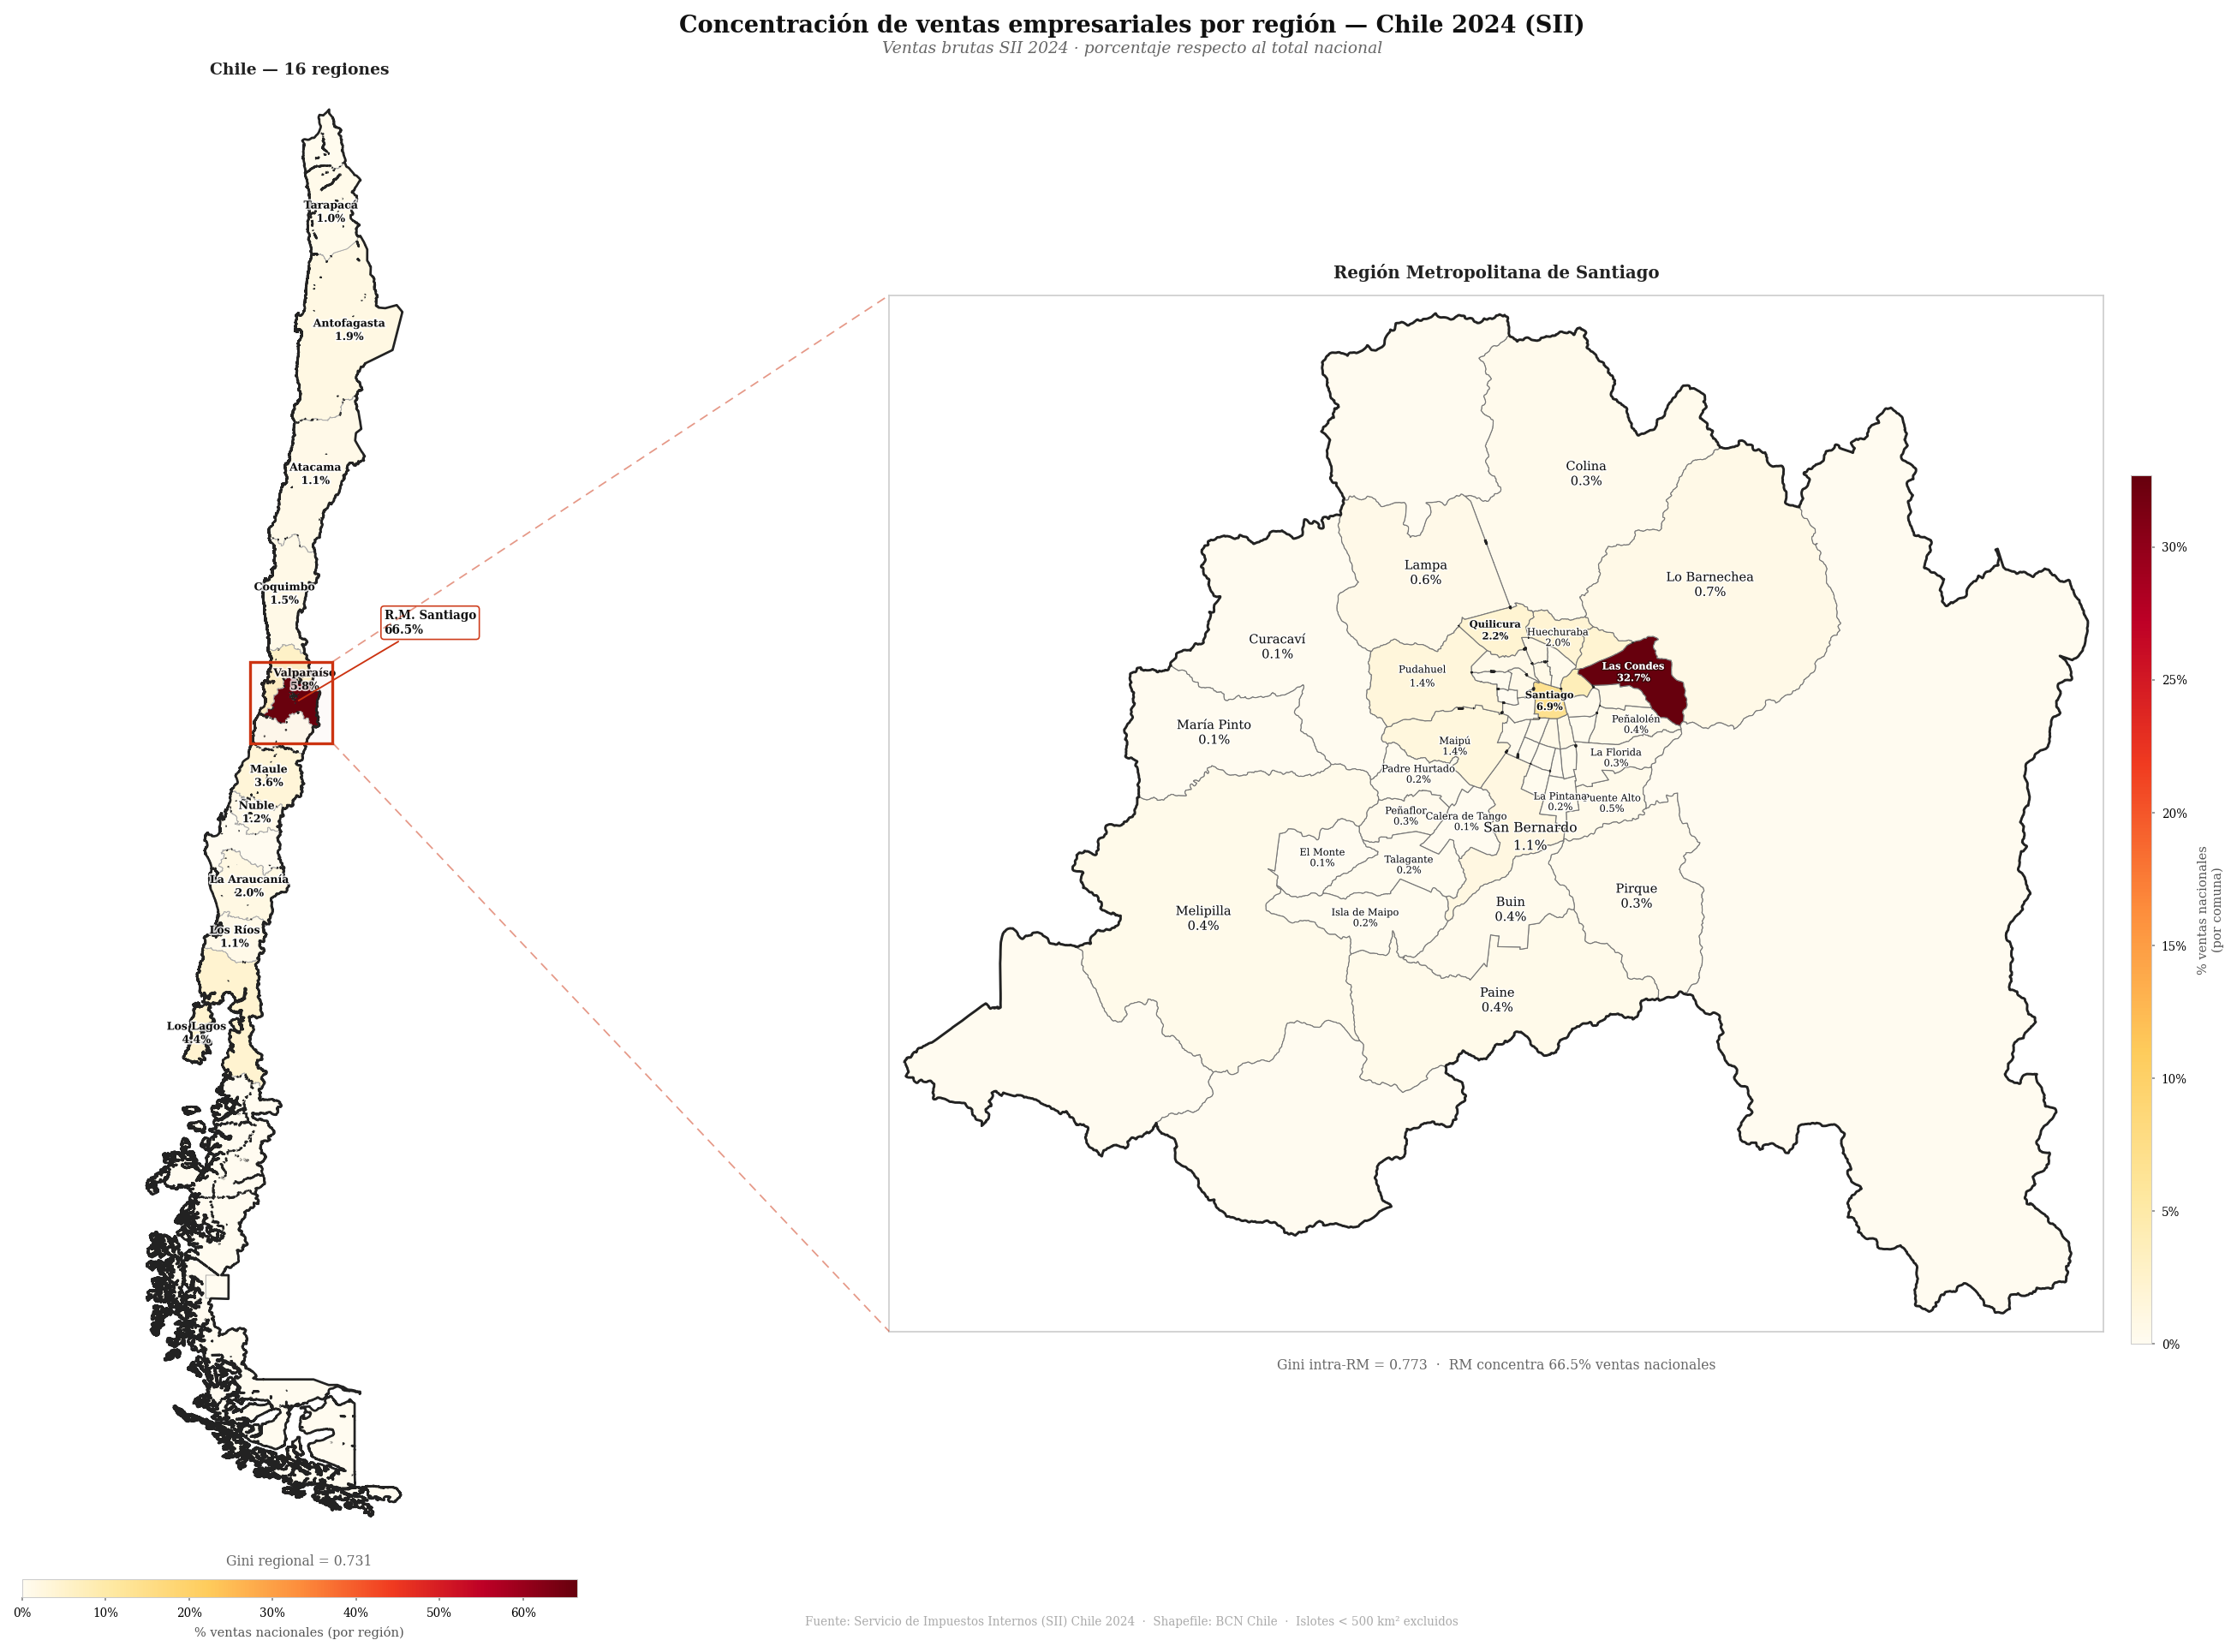

✓ Figura generada
  Chile: 16 regiones | Gini = 0.731 | RM: 66.5%
  Santiago: 52 comunas | Gini RM = 0.773 | Top: 32.7% (Las Condes)


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# 4. FIGURA COMBINADA — diseño profesional v7
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

# Comunas centrales pequeñas: se colorean pero NO se etiquetan
COMUNAS_SIN_LABEL = {
    "Independencia", "Quinta Normal", "Conchalí", "Renca",
    "Pedro Aguirre Cerda", "San Joaquín", "San Miguel", "La Cisterna",
    "Lo Espejo", "Cerro Navia", "Lo Prado", "Recoleta",
    "La Granja", "Macul", "San Ramón", "El Bosque",
    "Estación Central", "Cerrillos","Ñuñoa","Providencia","Vitacura","La Reina"
}

# Ajustes manuales de posición para etiquetas específicas (dx, dy en grados)
LABEL_OFFSET_MANUAL = {
    "Las Condes": (0.0, 0.012),   # mueve el label hacia arriba
}

# ── Número consistente para la RM ─────────────────────────────────────────────
_rm_mask      = reg_data["region"].str.contains("Metropolitana", na=False)
pct_rm_region = float(reg_data.loc[_rm_mask, "pct"].values[0])

# ── Normalizaciones independientes ────────────────────────────────────────────
norm_cl   = Normalize(vmin=0, vmax=reg_merged["pct"].max())
norm_stgo = Normalize(vmin=0, vmax=rm_merged["pct_nac"].max())

# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13), facecolor="white")
fig.patch.set_facecolor("white")

ax_cl    = fig.add_axes([0.02,  0.07,  0.24,  0.86])
ax_stgo  = fig.add_axes([0.395, 0.08,  0.525, 0.835])
ax_cbar1 = fig.add_axes([0.02,  0.028, 0.24,  0.011])
ax_cbar2 = fig.add_axes([0.932, 0.18,  0.009, 0.52])

for _a in (ax_cl, ax_stgo):
    _a.set_facecolor("white")
    for sp in _a.spines.values():
        sp.set_visible(False)
    _a.set_xticks([])
    _a.set_yticks([])

# ══════════════════════════════════════════════════════════════════════════════
# 4a. PANEL CHILE
# ══════════════════════════════════════════════════════════════════════════════
reg_merged.plot(
    column="pct", cmap=CMAP, norm=norm_cl,
    ax=ax_cl, linewidth=0.45, edgecolor="#aaaaaa",
    missing_kwds={"color": "#eeeeee"},
)
reg_merged.dissolve().boundary.plot(
    ax=ax_cl, color="#222222", linewidth=1.3, zorder=5,
)

b_cl = reg_merged.total_bounds
ax_cl.set_xlim(b_cl[0] - 0.5, b_cl[2] + 2.2)
ax_cl.set_ylim(b_cl[1] - 0.3, b_cl[3] + 0.5)

for _, row in reg_merged.sort_values("pct", ascending=False).iterrows():
    pct = row["pct"]
    if pd.isna(pct) or pct < 0.8:
        continue
    pt     = row.geometry.representative_point()
    lum    = sum(c * w for c, w in zip(CMAP(norm_cl(pct))[:3], (0.2126, 0.7152, 0.0722)))
    tc     = "white" if lum < 0.48 else "#111111"
    stroke = "#00000077" if tc == "white" else "#ffffffcc"
    etq    = row.get("etiqueta") or row["Region"]
    lbl    = f"{etq}\n{pct:.1f}%"
    is_rm  = "Metropolitana" in str(row.get("region", row["Region"]))
    if is_rm:
        ax_cl.annotate(
            lbl, xy=(pt.x, pt.y),
            xytext=(pt.x + 3.0, pt.y + 1.8),
            fontsize=6.5, fontweight="bold", fontfamily="DejaVu Serif",
            color="#111111", ha="left", va="bottom", linespacing=1.3,
            annotation_clip=False,
            arrowprops=dict(arrowstyle="-", color="#cc3311",
                            lw=0.9, connectionstyle="arc3,rad=0.0"),
            bbox=dict(boxstyle="round,pad=0.28", fc="white",
                      ec="#cc331177", lw=0.8, alpha=0.95),
            zorder=9,
        )
    else:
        ax_cl.text(
            pt.x, pt.y, lbl,
            ha="center", va="center",
            fontsize=6.0, fontweight="bold", fontfamily="DejaVu Serif",
            color=tc, linespacing=1.25,
            path_effects=[pe.withStroke(linewidth=1.8, foreground=stroke)],
            zorder=6,
        )

_cl_pos = ax_cl.get_position()
fig.text(_cl_pos.x0 + _cl_pos.width / 2, _cl_pos.y1 + 0.008,
         f"Chile — {len(reg_data)} regiones",
         ha="center", va="bottom", fontsize=9, fontweight="bold",
         fontfamily="DejaVu Serif", color="#222222")
fig.text(_cl_pos.x0 + _cl_pos.width / 2, _cl_pos.y0 - 0.016,
         f"Gini regional = {gini_cl:.3f}",
         ha="center", va="top", fontsize=7.5,
         fontfamily="DejaVu Serif", color="#666666")

# ══════════════════════════════════════════════════════════════════════════════
# 4b. PANEL SANTIAGO — RM completa, etiquetas selectivas
# ══════════════════════════════════════════════════════════════════════════════
rm_merged.plot(
    column="pct_nac", cmap=CMAP, norm=norm_stgo,
    ax=ax_stgo, linewidth=0.55, edgecolor="#777777",
    missing_kwds={"color": "#eeeeee"},
)
rm_merged.dissolve().boundary.plot(
    ax=ax_stgo, color="#222222", linewidth=1.4, zorder=5,
)

_px, _py  = 0.025, 0.025
b_stgo    = rm_merged.total_bounds
_x_range  = (b_stgo[2] + _px) - (b_stgo[0] - _px)
_ax_w_in  = 18 * 0.525
_pts_per_deg = (_ax_w_in * 72) / _x_range

for _, row in rm_merged.iterrows():
    pct    = row["pct_nac"]
    comuna = row["Comuna"]

    # Omitir comunas centrales pequeñas
    if comuna in COMUNAS_SIN_LABEL:
        continue
    # Omitir comunas sin ventas relevantes (rurales con pct muy bajo)
    if pct < 0.1:
        continue

    pt  = row.geometry.representative_point()
    lum = sum(c * w for c, w in zip(CMAP(norm_stgo(pct))[:3], (0.2126, 0.7152, 0.0722)))
    tc  = "white" if lum < 0.48 else "#111111"
    stroke = "#00000066" if tc == "white" else "#ffffffcc"

    # ── Aplicar ajuste manual de posición si corresponde ──────────────────────
    dx, dy = LABEL_OFFSET_MANUAL.get(comuna, (0.0, 0.0))
    px, py = pt.x + dx, pt.y + dy

    # Tamaño geográfico máximo
    b    = row.geometry.bounds
    w_deg = b[2] - b[0]
    h_deg = b[3] - b[1]
    min_dim_pts = min(w_deg, h_deg) * _pts_per_deg
    fs_geo = (min_dim_pts * 0.85) / (13 * 0.55)
    fs_geo = float(np.clip(fs_geo, 5.5, 10.0))

    # Tamaño por importancia económica
    if pct >= 5:
        fs_econ, fw = 10.0, "bold"
    elif pct >= 2:
        fs_econ, fw = 8.5,  "bold"
    elif pct >= 0.8:
        fs_econ, fw = 7.5,  "normal"
    else:
        fs_econ, fw = 7.0,  "normal"

    fs = min(fs_econ, fs_geo)

    ax_stgo.text(
        px, py, f"{comuna}\n{pct:.1f}%",
        ha="center", va="center",
        fontsize=fs, fontweight=fw, fontfamily="DejaVu Serif",
        color=tc, linespacing=1.3,
        path_effects=[pe.withStroke(linewidth=max(1.5, fs * 0.18),
                                    foreground=stroke)],
        zorder=6,
    )

ax_stgo.set_xlim(b_stgo[0] - _px, b_stgo[2] + _px)
ax_stgo.set_ylim(b_stgo[1] - _py, b_stgo[3] + _py)

for sp in ax_stgo.spines.values():
    sp.set_visible(True)
    sp.set_edgecolor("#cccccc")
    sp.set_linewidth(0.8)

_st_pos = ax_stgo.get_position()
fig.text(_st_pos.x0 + _st_pos.width / 2, _st_pos.y1 + 0.008,
         "Región Metropolitana de Santiago",
         ha="center", va="bottom", fontsize=9.5, fontweight="bold",
         fontfamily="DejaVu Serif", color="#222222")
fig.text(_st_pos.x0 + _st_pos.width / 2, _st_pos.y0 - 0.016,
         f"Gini intra-RM = {gini_rm:.3f}  ·  RM concentra {pct_rm_region:.1f}% ventas nacionales",
         ha="center", va="top", fontsize=7.5,
         fontfamily="DejaVu Serif", color="#666666")

# ══════════════════════════════════════════════════════════════════════════════
# 4c. ZOOM: rectángulo + líneas
# ══════════════════════════════════════════════════════════════════════════════
rm_geom_cl = reg_merged[
    reg_merged["Region"].str.contains("Metropolitana", na=False)
].geometry.union_all()
rb = rm_geom_cl.bounds

_pad = 0.42
ax_cl.add_patch(mpatches.Rectangle(
    (rb[0] - _pad, rb[1] - _pad),
    (rb[2] - rb[0]) + 2 * _pad,
    (rb[3] - rb[1]) + 2 * _pad,
    linewidth=1.6, edgecolor="#cc3311",
    facecolor="#cc331106", zorder=8, clip_on=False,
))

def d2f(ax, xd, yd):
    disp = ax.transData.transform((xd, yd))
    return fig.transFigure.inverted().transform(disp)

f_top_r = d2f(ax_cl,   rb[2] + _pad,    rb[3] + _pad)
f_bot_r = d2f(ax_cl,   rb[2] + _pad,    rb[1] - _pad)
f_top_s = d2f(ax_stgo, b_stgo[0] - _px, b_stgo[3] + _py)
f_bot_s = d2f(ax_stgo, b_stgo[0] - _px, b_stgo[1] - _py)

for (x0, y0), (x1, y1) in [(f_top_r, f_top_s), (f_bot_r, f_bot_s)]:
    fig.add_artist(plt.Line2D(
        [x0, x1], [y0, y1],
        transform=fig.transFigure,
        color="#cc3311", linewidth=0.85,
        linestyle=(0, (6, 4)), alpha=0.5, zorder=20,
    ))

# ══════════════════════════════════════════════════════════════════════════════
# 4d. COLORBARS
# ══════════════════════════════════════════════════════════════════════════════
sm1 = ScalarMappable(cmap=CMAP, norm=norm_cl)
sm1.set_array([])
cb1 = fig.colorbar(sm1, cax=ax_cbar1, orientation="horizontal")
cb1.set_label("% ventas nacionales (por región)",
              fontsize=7, fontfamily="DejaVu Serif", color="#555555", labelpad=4)
cb1.ax.tick_params(labelsize=6.5, color="#888888", length=2)
cb1.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
for sp in cb1.ax.spines.values():
    sp.set_color("#cccccc"); sp.set_linewidth(0.5)

sm2 = ScalarMappable(cmap=CMAP, norm=norm_stgo)
sm2.set_array([])
cb2 = fig.colorbar(sm2, cax=ax_cbar2, orientation="vertical")
cb2.set_label("% ventas nacionales\n(por comuna)",
              fontsize=7, fontfamily="DejaVu Serif", color="#555555", labelpad=6)
cb2.ax.tick_params(labelsize=6.5, color="#888888", length=2)
cb2.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
for sp in cb2.ax.spines.values():
    sp.set_color("#cccccc"); sp.set_linewidth(0.5)

# ══════════════════════════════════════════════════════════════════════════════
# 4e. TÍTULO PRINCIPAL Y PIE
# ══════════════════════════════════════════════════════════════════════════════
fig.text(0.5, 0.977,
         f"Concentración de ventas empresariales por región — Chile {ANIO_CL} (SII)",
         ha="center", va="top", fontsize=13, fontweight="bold",
         fontfamily="DejaVu Serif", color="#111111")
fig.text(0.5, 0.960,
         "Ventas brutas SII 2024 · porcentaje respecto al total nacional",
         ha="center", va="top", fontsize=9,
         fontfamily="DejaVu Serif", color="#666666", style="italic")
fig.text(0.5, 0.010,
         (f"Fuente: Servicio de Impuestos Internos (SII) Chile {ANIO_CL}  ·  "
          "Shapefile: BCN Chile  ·  Islotes < 500 km² excluidos"),
         ha="center", va="bottom", fontsize=6.5,
         fontfamily="DejaVu Serif", color="#aaaaaa")

# ══════════════════════════════════════════════════════════════════════════════
# 5. OUTPUT
# ══════════════════════════════════════════════════════════════════════════════
display(fig)
plt.close()

print("✓ Figura generada")
print(f"  Chile: {len(reg_data)} regiones | Gini = {gini_cl:.3f} | RM: {pct_rm_region:.1f}%")
print(f"  Santiago: {len(rm_merged)} comunas | Gini RM = {gini_rm:.3f} | Top: {top1_rm['pct_nac']:.1f}% ({top1_rm['comuna']})")